# Task 2.1 — Dataset Selection and Setup

**Paper:** *A Dual Coordinate Descent Method for Large-scale Linear SVM*  
**Student:** Navnit Naman | Roll: 230085

In [1]:
# Set random seed at the top for reproducibility
import numpy as np
import random
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


## Dataset Justification

**Dataset:** `sklearn.datasets.make_classification` — a synthetic binary classification dataset.

**What the dataset is:** A programmatically generated binary classification dataset with 1,500 samples, 50 features (30 informative, 10 redundant, 10 noise), and labels converted to {−1, +1} to match the SVM convention used throughout the paper (Eq. 1 and Eq. 4).

**Why it is a reasonable testbed:** The paper proposes DCD for linear SVM binary classification — exactly the problem this dataset addresses. The method's core algorithm (Algorithm 1) requires only instance-label pairs (xᵢ, yᵢ) with yᵢ ∈ {−1, +1} (Section 1), which this dataset provides directly. With 1,500 instances and 50 features, the dataset is large enough to observe multiple outer iterations of the coordinate descent loop and to produce meaningful convergence plots, while remaining small enough to run on CPU within a few seconds as required by the exam constraints.

**Limitations compared to the paper's original datasets:** The paper evaluates on large sparse datasets (news20: 15,935 instances × 62,061 features; rcv1: 677,399 instances × 47,236 features; astro-physics) that are extremely sparse (n̄ ≪ n). Our synthetic dataset is dense (all 50 features are populated for every instance), which means the sparsity-driven O(n̄) efficiency advantage claimed by the paper does not manifest here. Convergence on our dataset may be faster per iteration simply because l is small, rather than because of the algorithmic speedup the paper emphasizes. The original paper's datasets are also text corpora with real-world class imbalance, which our balanced synthetic data does not replicate.

**Preprocessing steps:** Labels are mapped from {0, 1} to {−1, +1} to match the SVM formulation. Features are standardized (zero mean, unit variance) using `StandardScaler`, since Linear SVM performance is sensitive to feature scales. The dataset is split into 80% train and 20% test.

In [2]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset
X, y = make_classification(
    n_samples=1500,
    n_features=50,
    n_informative=30,
    n_redundant=10,
    n_clusters_per_class=1,
    random_state=RANDOM_SEED
)

# Convert labels {0, 1} -> {-1, +1} as required by SVM (Eq. 1 in paper)
y = 2 * y - 1

# Standardize features
scaler = StandardScaler()
X_all = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Label distribution (train): +1: {(y_train==1).sum()}, -1: {(y_train==-1).sum()}")
print(f"Label values: {np.unique(y_train)}")

Training set: 1200 samples, 50 features
Test set:     300 samples
Label distribution (train): +1: 607, -1: 593
Label values: [-1  1]


The cell above generates the synthetic binary classification dataset using `make_classification`, maps labels to {−1, +1} as required by the SVM primal formulation in Eq. (1) of the paper, standardizes features, and splits into train/test sets. This preprocessing ensures numerical stability for the dual coordinate descent iterations.

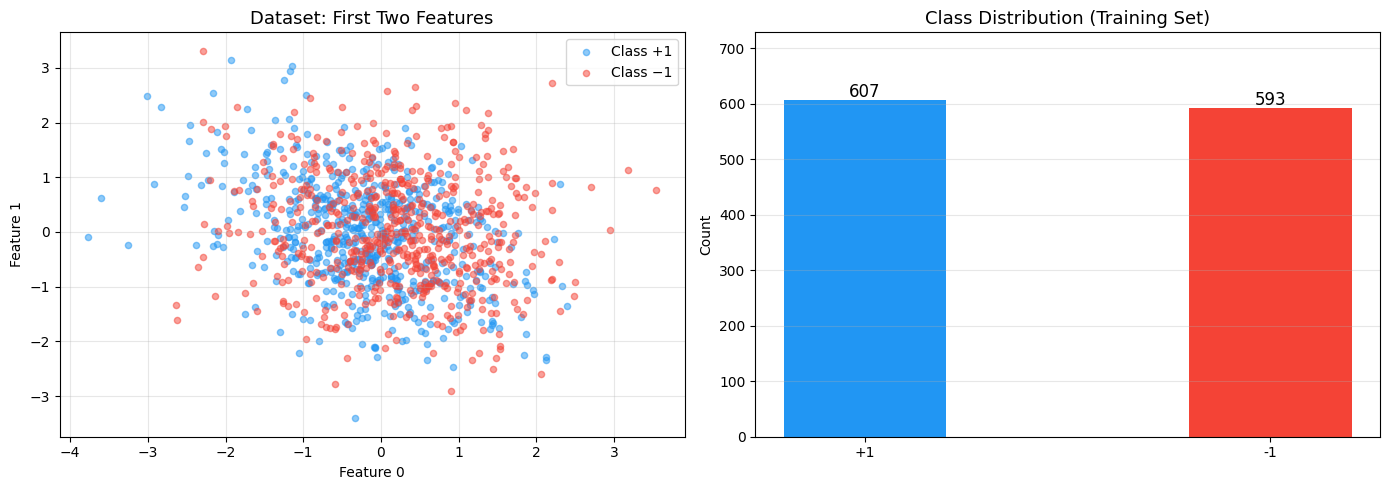

Saved: results/dataset_visualization.png


In [3]:
# Visualize dataset (first two features for illustration)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot (first 2 features)
ax = axes[0]
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
           alpha=0.5, label='Class +1', c='#2196F3', s=20)
ax.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], 
           alpha=0.5, label='Class −1', c='#F44336', s=20)
ax.set_title('Dataset: First Two Features', fontsize=13)
ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')
ax.legend(); ax.grid(alpha=0.3)

# Label distribution
ax = axes[1]
label_counts = {'+1': (y_train==1).sum(), '-1': (y_train==-1).sum()}
bars = ax.bar(label_counts.keys(), label_counts.values(), 
              color=['#2196F3', '#F44336'], width=0.4)
for bar, val in zip(bars, label_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(val), ha='center', fontsize=12)
ax.set_title('Class Distribution (Training Set)', fontsize=13)
ax.set_ylabel('Count'); ax.set_ylim(0, max(label_counts.values()) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/dataset_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/dataset_visualization.png")

The scatter plot shows the distribution of training samples in the space of the first two features; classes overlap somewhat, demonstrating that this is not a trivially separable dataset. The bar chart confirms balanced class distribution, which is typical of `make_classification` defaults and avoids class-imbalance confounds when measuring accuracy.